Mount Drive and imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import time

from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

SAVE_DIR = '/content/drive/MyDrive/AI And ML/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)


In [3]:
print("TensorFlow Version:", tf.__version__)

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Import dataset

In [4]:
data_dir = "/content/drive/MyDrive/AI And ML/Sign Language Detection/Train"

Check and Remove corrupted images

In [5]:

def check_corrupted_images(folder_path):
    corrupted = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                corrupted.append(file_path)
    return corrupted

corrupted_images = check_corrupted_images(data_dir)
print("Total corrupted images:", len(corrupted_images))

for img_path in corrupted_images:
    os.remove(img_path)
print("Corrupted images removed.")

Total corrupted images: 266
Corrupted images removed.


Data Generators

In [6]:
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1

)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print('Number of classes:', train_data.num_classes)
print('Class labels:', train_data.class_indices)

NUM_CLASSES = train_data.num_classes

print('Training Samples:', train_data.samples)
print('Validation Samples:', val_data.samples)
print('Training Split: 80%')
print('Validation Split: 20%')

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Number of classes: 38
Class labels: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '4': 32, '5': 33, '6': 34, '7': 35, '8': 36, '9': 37}
Training Samples: 8648
Validation Samples: 2144
Training Split: 80%
Validation Split: 20%


Total image in dataset

In [7]:
total_images = 0

class_labels = list(train_data.class_indices.keys())

for cls in class_labels:

    folder = os.path.join(data_dir, cls)

    total_images += len(os.listdir(folder))

print("Total Images in Dataset:", total_images)

Total Images in Dataset: 10792


Dataset Distribution

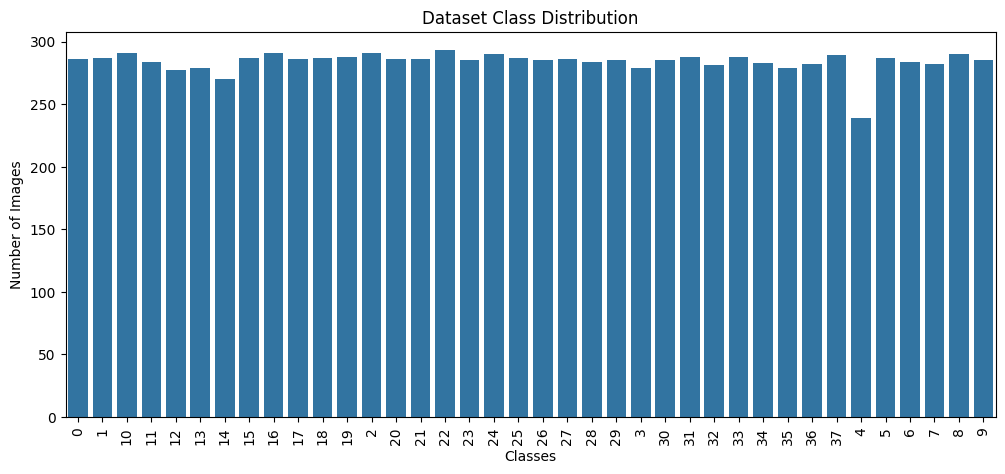

In [8]:

class_counts = []

class_labels = list(train_data.class_indices.keys())

for cls in class_labels:

    folder = os.path.join(data_dir, cls)

    class_counts.append(len(os.listdir(folder)))


plt.figure(figsize=(12,5))

sns.barplot(
    x=class_labels,
    y=class_counts
)

plt.xticks(rotation=90)

plt.title("Dataset Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

Visualize Sample Images

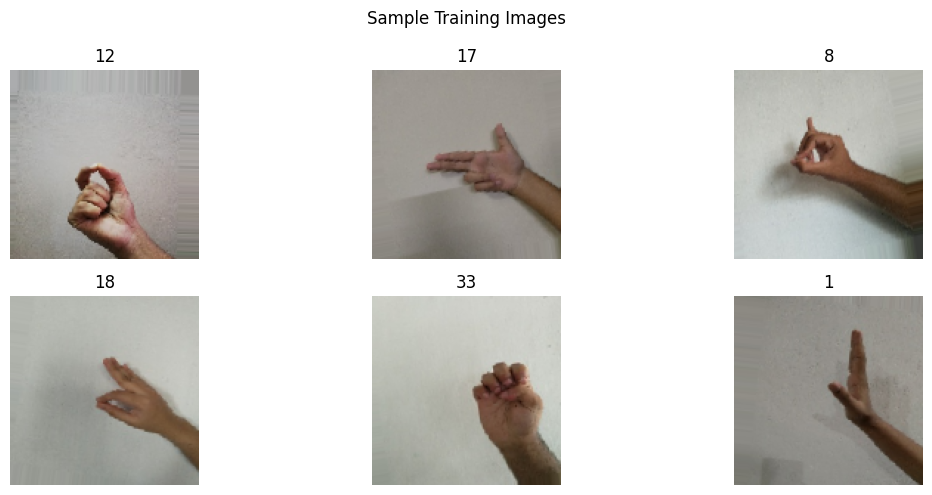

In [9]:
images, labels = next(train_data)

class_names = {v:k for k,v in train_data.class_indices.items()}


plt.figure(figsize=(12,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    class_idx = labels[i].argmax()

    plt.title(class_names[class_idx])

    plt.axis('off')


plt.suptitle("Sample Training Images")

plt.tight_layout()

plt.show()

In [13]:
import json
from tensorflow.keras.callbacks import ModelCheckpoint

def get_callbacks_adam(model_name):
    """Fresh Adam callbacks every call. Pass a model_name to auto-save best weights."""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{SAVE_DIR}/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

def get_callbacks_sgd(model_name):
    """Fresh SGD callbacks with higher patience. Pass a model_name to auto-save best weights."""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{SAVE_DIR}/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

def save_history(history, name):
    """Save training history to Drive so plots survive crashes."""
    with open(f'{SAVE_DIR}/{name}_history.json', 'w') as f:
        json.dump(history.history, f)
    print(f'History saved: {name}')

def load_history(name):
    """Load a previously saved history for plotting."""
    with open(f'{SAVE_DIR}/{name}_history.json', 'r') as f:
        return json.load(f)

Baseline CNN Model

In [11]:
baseline_model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,830 (25.00 MB)

 Trainable params: 6,553,830 (25.00 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model

In [14]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

baseline_train_time = time.time() - start



Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 93s 330ms/step - accuracy: 0.8802 - loss: 0.3666 - val_accuracy: 0.7752 - val_loss: 1.1043
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 80s 295ms/step - accuracy: 0.8860 - loss: 0.3557 - val_accuracy: 0.7570 - val_loss: 1.1640
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 72s 267ms/step - accuracy: 0.8870 - loss: 0.3465 - val_accuracy: 0.7449 - val_loss: 1.1781
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 75s 277ms/step - accuracy: 0.8873 - loss: 0.3433 - val_accuracy: 0.7598 - val_loss: 1.1761
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 74s 274ms/step - accuracy: 0.8930 - loss: 0.3296 - val_accuracy: 0.7528 - val_loss: 1.2822
Epoch 6/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 73s 270ms/step - accuracy: 0.8893 - loss: 0.3362 - val_accuracy: 0.7607 - val_loss: 1.1334
Epoch 7/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 73s 269ms/step - accuracy: 0.8942 - loss: 0.3247 - val_accuracy: 0.7439 - val_loss: 1.2856
Epoch 8/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 74s 272ms/step - accuracy: 0.8936 - loss: 0

In [15]:

baseline_model.save(f'{SAVE_DIR}/baseline_model.keras')
save_history(history_baseline, 'baseline')
print(f'Baseline done in {baseline_train_time:.1f}s')

History saved: baseline
Baseline done in 2253.9s


Plot Baseline Training Curves

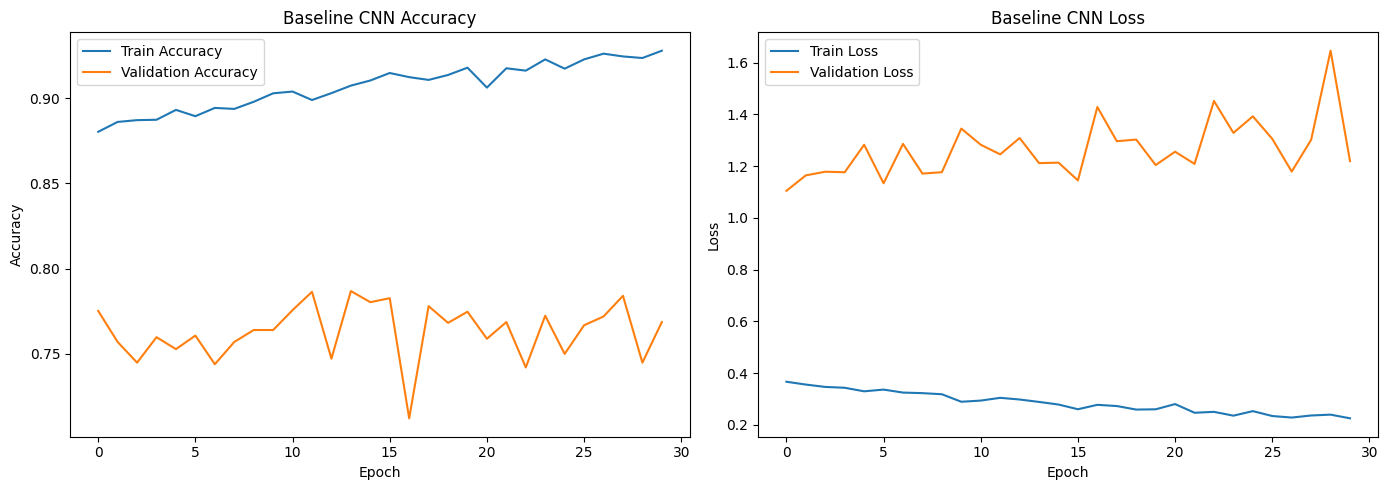

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluate Baseline Model

In [18]:
val_preds = baseline_model.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes

print("Baseline CNN Classification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_data.class_indices.keys())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step
Baseline CNN Classification Report
              precision    recall  f1-score   support

           0       0.57      0.77      0.66        57
           1       0.71      0.74      0.72        57
          10       0.72      0.81      0.76        58
          11       0.84      0.82      0.83        56
          12       0.84      0.78      0.81        55
          13       0.68      0.73      0.70        55
          14       0.56      0.61      0.58        54
          15       0.93      0.72      0.81        57
          16       0.88      0.88      0.88        58
          17       0.95      0.74      0.83        57
          18       0.70      0.77      0.73        57
          19       0.89      0.58      0.70        57
           2       0.65      0.84      0.74        58
          20       0.70      0.77      0.73        57
          21       0.93      0.72      0.81        57
          22       0.84      0.81      0.82        58
     

Confusion Matrix

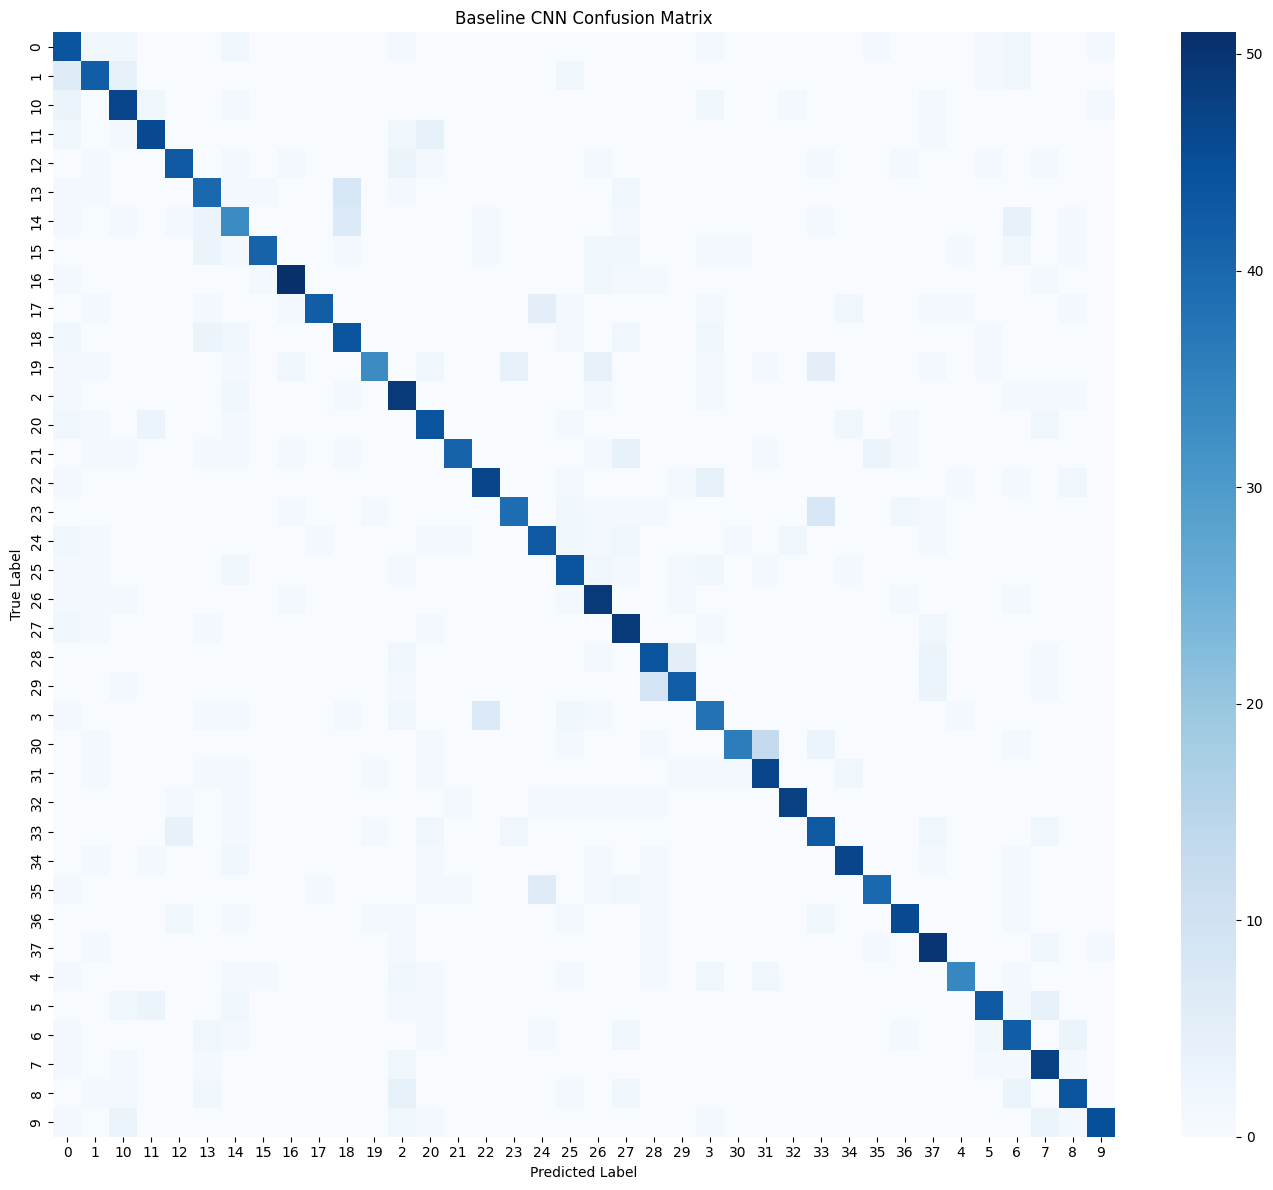

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=train_data.class_indices.keys(),
    yticklabels=train_data.class_indices.keys()
)
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Sample Inference on Baseline Model

In [20]:
def show_predictions(model, data, title):
    data.reset()
    sample_imgs, sample_labels = next(data)
    preds = model.predict(sample_imgs)

    plt.figure(figsize=(12, 5))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(sample_imgs[i])
        true_cls = class_names[sample_labels[i].argmax()]
        pred_cls = class_names[np.argmax(preds[i])]
        color = 'green' if true_cls == pred_cls else 'red'
        plt.title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=8)
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Show baseline predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


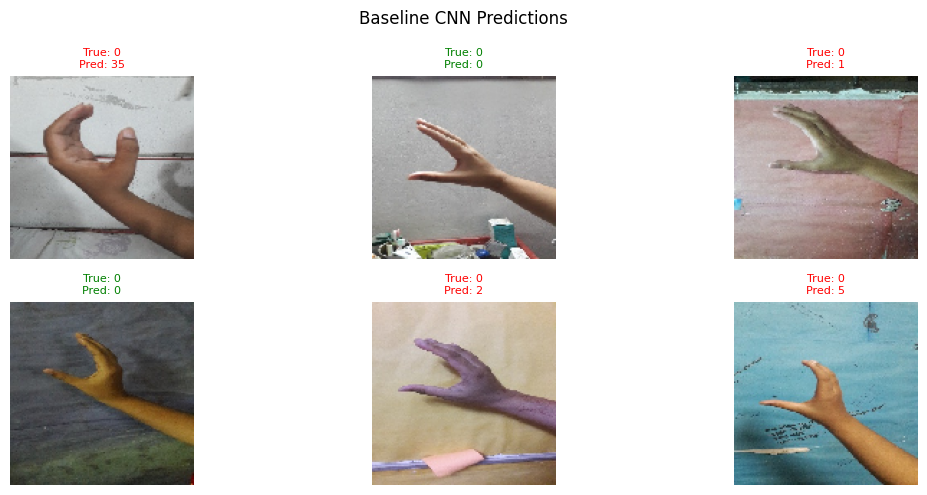

In [21]:
show_predictions(baseline_model, val_data, "Baseline CNN Predictions")

Deeper CNN Model (ADAM)

In [22]:
deep_model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 709,574 (2.71 MB)

 Trainable params: 708,422 (2.70 MB)

 Non-trainable params: 1,152 (4.50 KB)

Train Deeper Model with Adam

In [26]:
model_name = 'deep_cnn_adam'
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_deep = deep_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=get_callbacks_adam(model_name)
)

deep_train_time = time.time() - start

Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.0295 - loss: 3.7347
Epoch 1: val_accuracy improved from None to 0.02612, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 117s 362ms/step - accuracy: 0.0378 - loss: 3.6533 - val_accuracy: 0.0261 - val_loss: 5.1737 - learning_rate: 0.0010
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.0635 - loss: 3.4734
Epoch 2: val_accuracy improved from 0.02612 to 0.02659, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 81s 299ms/step - accuracy: 0.0777 - loss: 3.3872 - val_accuracy: 0.0266 - val_loss: 5.5333 - learning_rate: 0.0010
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 

In [27]:
deep_model.save(f'{SAVE_DIR}/deep_model_adam.keras')
save_history(history_deep, 'deep_adam')
print(f'Deep CNN (Adam) done in {deep_train_time:.1f}s')

History saved: deep_adam
Deep CNN (Adam) done in 2221.1s


Evaluate Deep CNN

In [28]:
val_preds2 = deep_model.predict(val_data)
y_pred2 = np.argmax(val_preds2, axis=1)

print("Deep CNN (Adam) Classification Report")
print(classification_report(
    y_true,
    y_pred2,
    target_names=list(train_data.class_indices.keys())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step
Deep CNN (Adam) Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        57
           1       0.98      0.75      0.85        57
          10       0.98      0.84      0.91        58
          11       0.92      0.82      0.87        56
          12       0.80      0.89      0.84        55
          13       0.94      0.85      0.90        55
          14       0.89      0.91      0.90        54
          15       0.94      0.82      0.88        57
          16       0.81      0.86      0.83        58
          17       1.00      0.86      0.92        57
          18       0.92      0.84      0.88        57
          19       0.86      0.74      0.79        57
           2       1.00      0.88      0.94        58
          20       0.28      0.96      0.43        57
          21       0.88      0.88      0.88        57
          22       0.88      0.84      0.86        58
  

Deep CNN Confusion Matrix

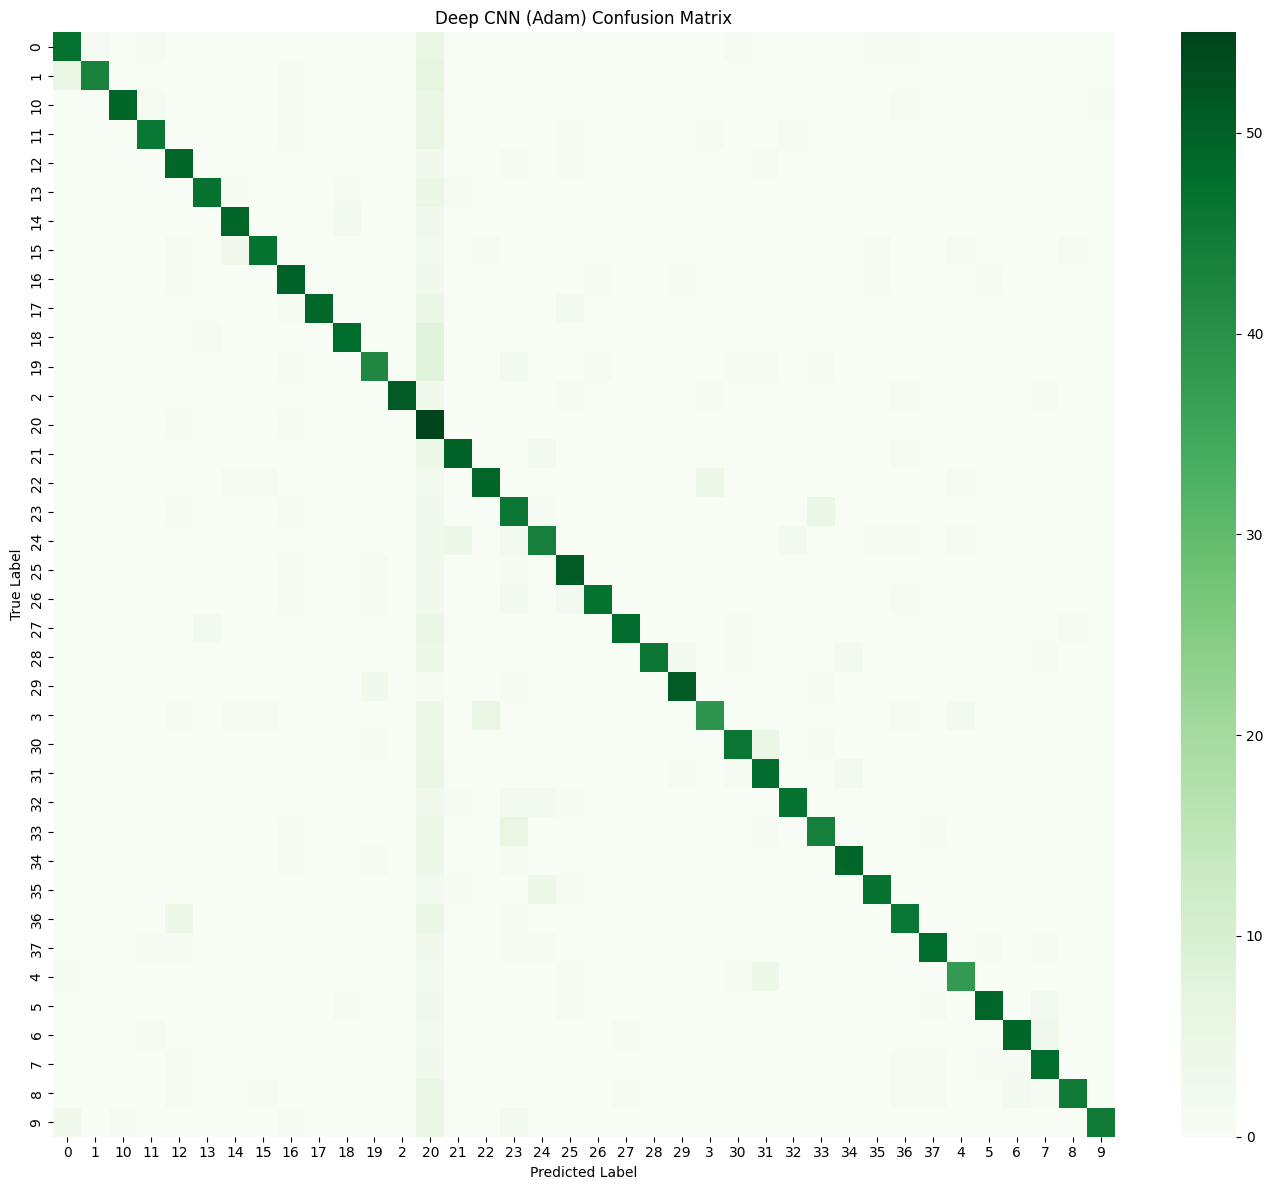

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step


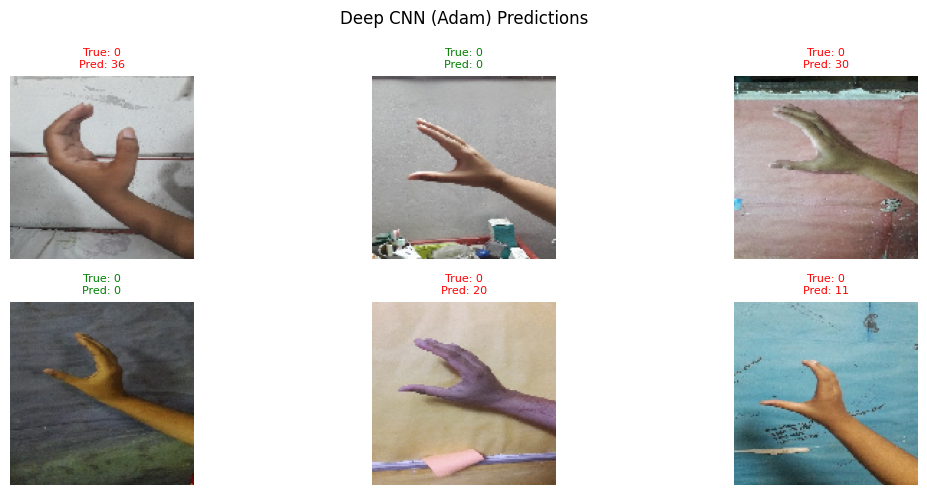

In [29]:
cm2 = confusion_matrix(y_true, y_pred2)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm2,
    annot=False,
    cmap='Greens',
    xticklabels=train_data.class_indices.keys(),
    yticklabels=train_data.class_indices.keys()
)
plt.title("Deep CNN (Adam) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

show_predictions(deep_model, val_data, "Deep CNN (Adam) Predictions")

Train Deeper Model with SGD

In [31]:
deep_model_sgd = tf.keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.05,
        momentum=0.9
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_sgd = deep_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=get_callbacks_sgd(model_name)
)

sgd_train_time = time.time() - start


Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.0315 - loss: 3.7322
Epoch 1: val_accuracy improved from None to 0.02752, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 102s 329ms/step - accuracy: 0.0308 - loss: 3.6747 - val_accuracy: 0.0275 - val_loss: 3.6532 - learning_rate: 0.0500
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.0387 - loss: 3.6385
Epoch 2: val_accuracy improved from 0.02752 to 0.03218, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 81s 297ms/step - accuracy: 0.0377 - loss: 3.6345 - val_accuracy: 0.0322 - val_loss: 3.6594 - learning_rate: 0.0500
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 

In [32]:
deep_model_sgd.save(f'{SAVE_DIR}/deep_model_sgd.keras')
save_history(history_sgd, 'deep_sgd')
print(f'Deep CNN (SGD) done in {sgd_train_time:.1f}s')

History saved: deep_sgd
Deep CNN (SGD) done in 2458.5s


Evaluate SGD Model

In [33]:
val_preds_sgd = deep_model_sgd.predict(val_data)
y_pred_sgd = np.argmax(val_preds_sgd, axis=1)

print("Deep CNN (SGD) Classification Report")
print(classification_report(
    y_true,
    y_pred_sgd,
    target_names=list(train_data.class_indices.keys())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step
Deep CNN (SGD) Classification Report
              precision    recall  f1-score   support

           0       0.90      0.77      0.83        57
           1       0.89      0.82      0.85        57
          10       0.94      0.86      0.90        58
          11       0.98      0.84      0.90        56
          12       0.82      0.84      0.83        55
          13       0.88      0.80      0.84        55
          14       1.00      0.78      0.88        54
          15       0.96      0.81      0.88        57
          16       0.65      0.91      0.76        58
          17       0.94      0.86      0.90        57
          18       0.82      0.86      0.84        57
          19       0.26      0.79      0.39        57
           2       0.93      0.91      0.92        58
          20       0.86      0.84      0.85        57
          21       0.76      0.88      0.81        57
          22       0.86      0.83      0.84        58
   

SGD Confusion Matrix

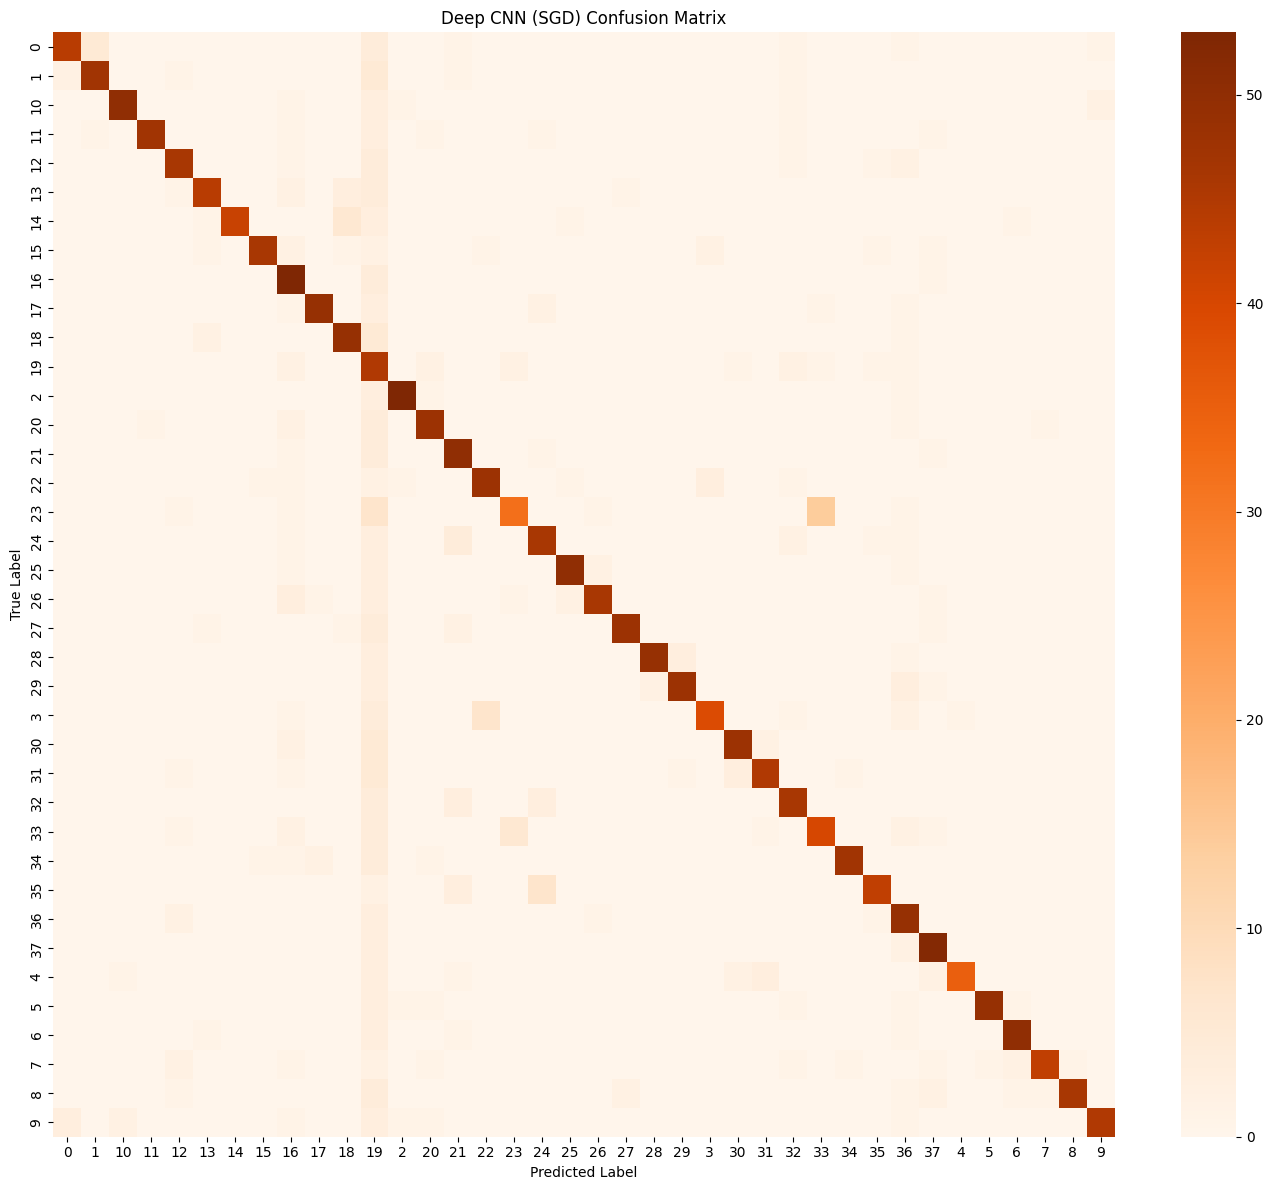

In [34]:
cm_sgd = confusion_matrix(y_true, y_pred_sgd)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_sgd,
    annot=False,
    cmap='Oranges',
    xticklabels=train_data.class_indices.keys(),
    yticklabels=train_data.class_indices.keys()
)
plt.title("Deep CNN (SGD) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



Show SGD Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


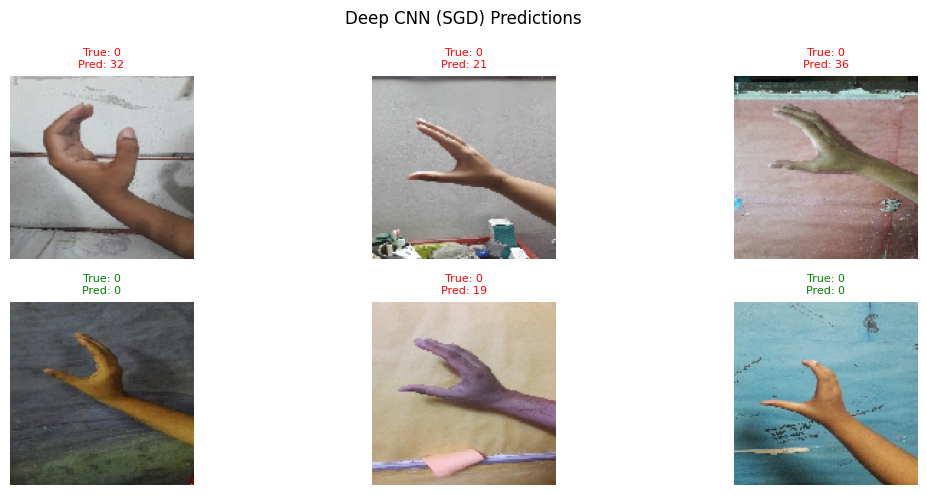

In [35]:
show_predictions(deep_model_sgd, val_data, "Deep CNN (SGD) Predictions")

Remove Dropout

In [37]:
no_dropout_model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

no_dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_dropout = no_dropout_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=get_callbacks_adam(model_name)
)

Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.0393 - loss: 3.6468
Epoch 1: val_accuracy improved from None to 0.02425, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 93s 317ms/step - accuracy: 0.0468 - loss: 3.6028 - val_accuracy: 0.0243 - val_loss: 3.8981 - learning_rate: 0.0010
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.0892 - loss: 3.3861
Epoch 2: val_accuracy improved from 0.02425 to 0.03638, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 81s 298ms/step - accuracy: 0.1071 - loss: 3.2620 - val_accuracy: 0.0364 - val_loss: 4.3634 - learning_rate: 0.0010
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0

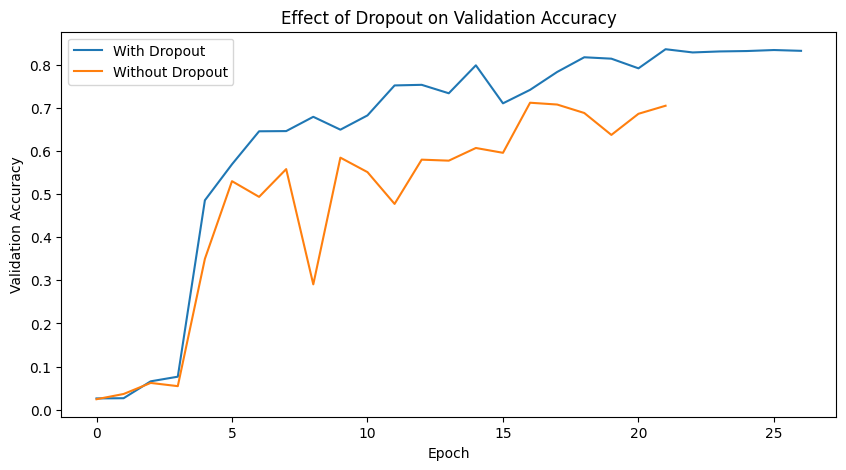

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history_deep.history['val_accuracy'], label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')
plt.title("Effect of Dropout on Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Comparison Plots: Baseline vs Deeper vs SGD

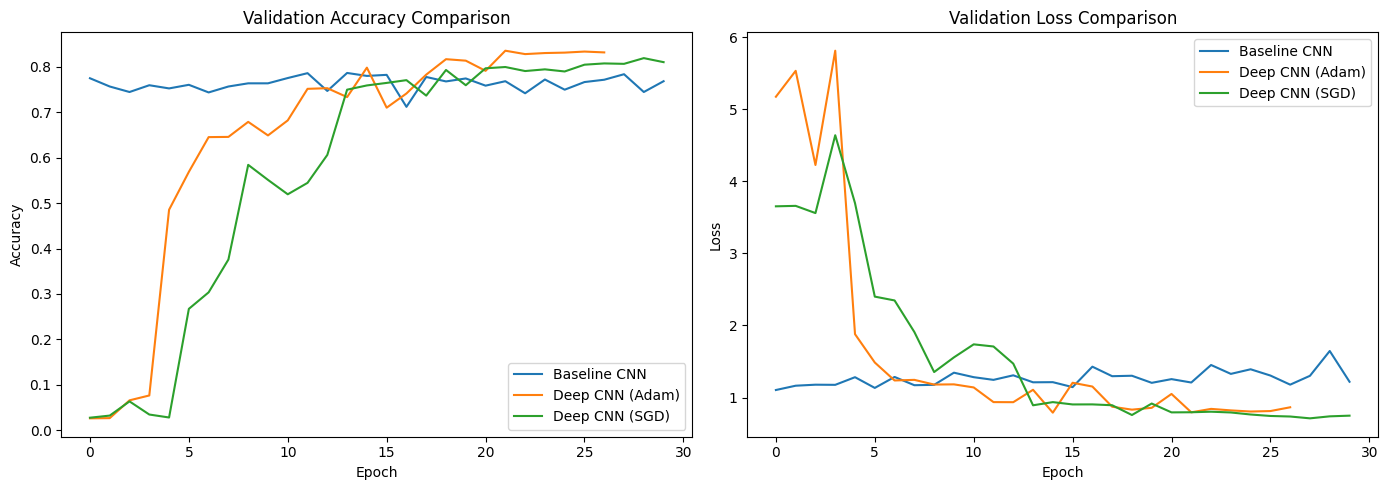

Baseline CNN Training Time  : 2253.9 seconds
Deep CNN (Adam) Training Time : 2221.1 seconds
Deep CNN (SGD) Training Time  : 2458.5 seconds


In [39]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN')
plt.plot(history_deep.history['val_accuracy'], label='Deep CNN (Adam)')
plt.plot(history_sgd.history['val_accuracy'], label='Deep CNN (SGD)')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline CNN')
plt.plot(history_deep.history['val_loss'], label='Deep CNN (Adam)')
plt.plot(history_sgd.history['val_loss'], label='Deep CNN (SGD)')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Baseline CNN Training Time  : {baseline_train_time:.1f} seconds")
print(f"Deep CNN (Adam) Training Time : {deep_train_time:.1f} seconds")
print(f"Deep CNN (SGD) Training Time  : {sgd_train_time:.1f} seconds")

Transfer Learning: MobileNetV2

In [40]:
img_size_tl = (224, 224)

train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1

)

val_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data_tl = train_datagen_tl.flow_from_directory(
    data_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data_tl = val_datagen_tl.flow_from_directory(
    data_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.


Build Transfer Learning Model

In [41]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Feature Extraction Training

In [43]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_tl = transfer_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=20,
    callbacks=get_callbacks_adam(model_name)
)

feature_extraction_time = time.time() - start



Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.2562 - loss: 2.7221
Epoch 1: val_accuracy improved from None to 0.61987, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 178s 581ms/step - accuracy: 0.3860 - loss: 2.1088 - val_accuracy: 0.6199 - val_loss: 1.2512 - learning_rate: 0.0010
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.5940 - loss: 1.2983
Epoch 2: val_accuracy improved from 0.61987 to 0.69590, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 151s 557ms/step - accuracy: 0.6129 - loss: 1.2214 - val_accuracy: 0.6959 - val_loss: 0.9600 - learning_rate: 0.0010
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━

In [44]:
save_history(history_tl, 'transfer_feature_extraction')
print(f'Feature extraction done in {feature_extraction_time:.1f}s')

History saved: transfer_feature_extraction
Feature extraction done in 2938.2s


 Fine-Tuning

In [46]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_ft = transfer_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=20,
    callbacks=get_callbacks_adam(model_name)
)

fine_tuning_time = time.time() - start



Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.6154 - loss: 1.2367
Epoch 1: val_accuracy improved from None to 0.78078, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 173s 568ms/step - accuracy: 0.6561 - loss: 1.0788 - val_accuracy: 0.7808 - val_loss: 0.7144 - learning_rate: 1.0000e-05
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.7434 - loss: 0.8020
Epoch 2: val_accuracy improved from 0.78078 to 0.78825, saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI And ML/saved_models/deep_cnn_adam_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 142s 525ms/step - accuracy: 0.7521 - loss: 0.7653 - val_accuracy: 0.7882 - val_loss: 0.7033 - learning_rate: 1.0000e-05
Epoch 3/20
271/271 ━━━━━━━━━━━━

In [47]:
transfer_model.save(f'{SAVE_DIR}/transfer_model_finetuned.keras')
save_history(history_ft, 'transfer_finetuned')
print(f'Fine-tuning done in {fine_tuning_time:.1f}s')

History saved: transfer_finetuned
Fine-tuning done in 2803.2s


Evaluate Transfer Learning Model

In [48]:
val_preds_tl = transfer_model.predict(val_data_tl)
y_pred_tl = np.argmax(val_preds_tl, axis=1)
y_true_tl = val_data_tl.classes

print("Transfer Learning Classification Report")
print(classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=list(train_data_tl.class_indices.keys())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step
Transfer Learning Classification Report
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        57
           1       0.93      0.91      0.92        57
          10       0.89      0.84      0.87        58
          11       0.86      1.00      0.93        56
          12       0.83      0.80      0.81        55
          13       0.76      0.82      0.79        55
          14       0.87      0.61      0.72        54
          15       0.91      0.72      0.80        57
          16       0.98      0.95      0.96        58
          17       0.90      0.81      0.85        57
          18       0.79      0.84      0.81        57
          19       0.94      0.77      0.85        57
           2       0.95      0.90      0.92        58
          20       0.86      0.95      0.90        57
          21       0.88      0.89      0.89        57
          22       0.82      0.86      0.84        58

Transfer learning confusion matrix

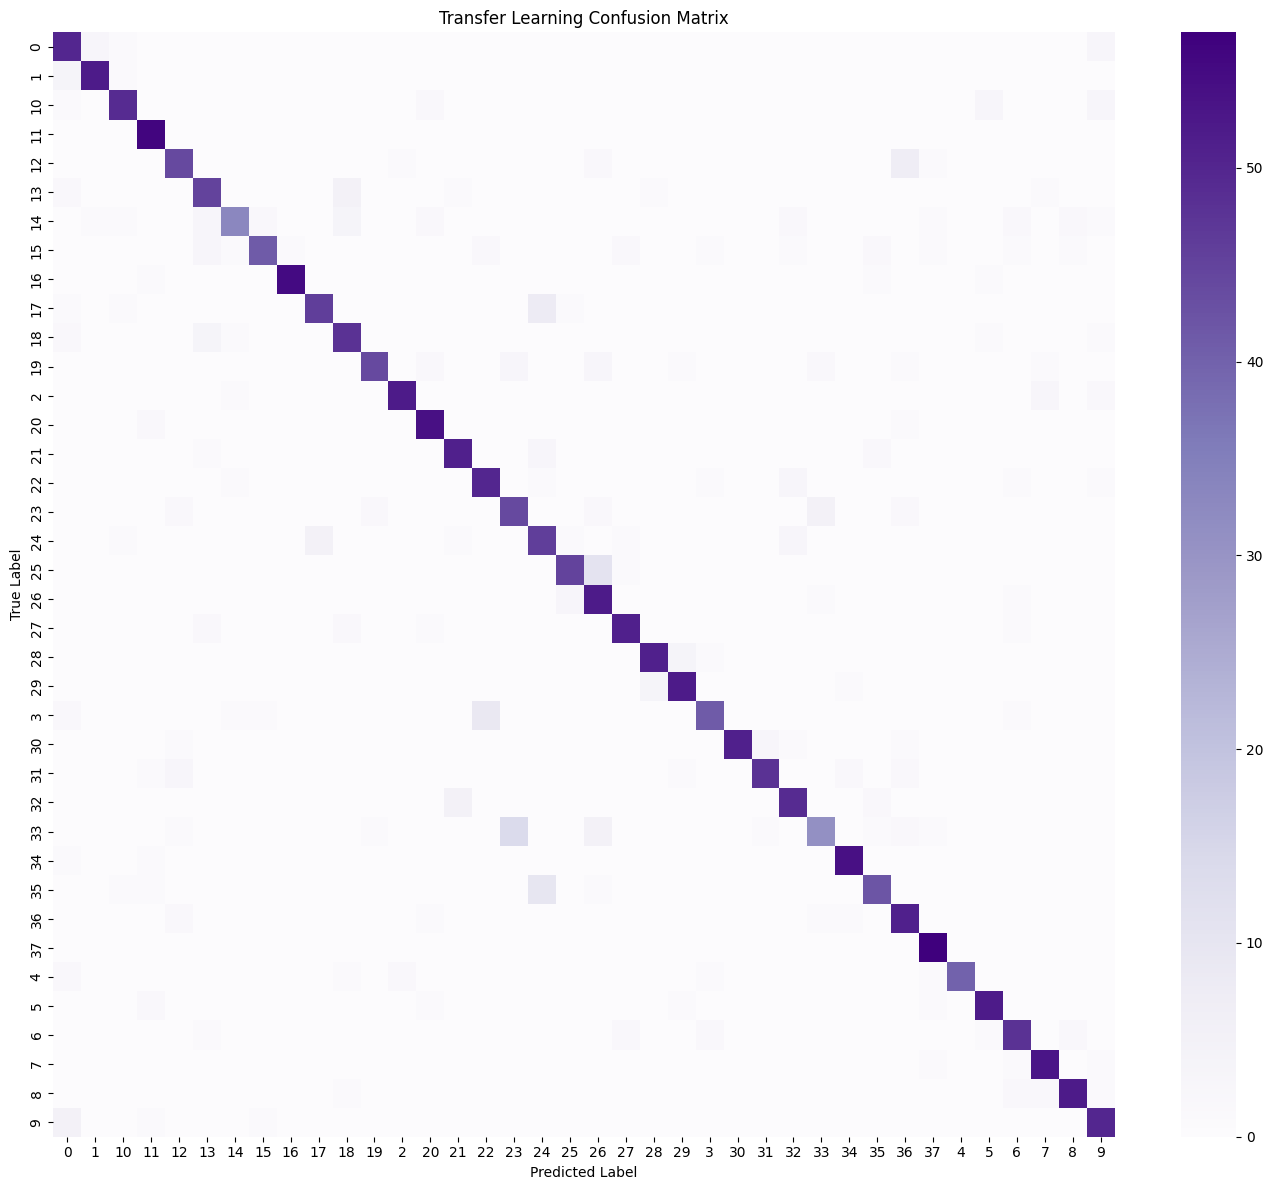

In [49]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_tl,
    annot=False,
    cmap='Purples',
    xticklabels=train_data_tl.class_indices.keys(),
    yticklabels=train_data_tl.class_indices.keys()
)
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Show transfer learning predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


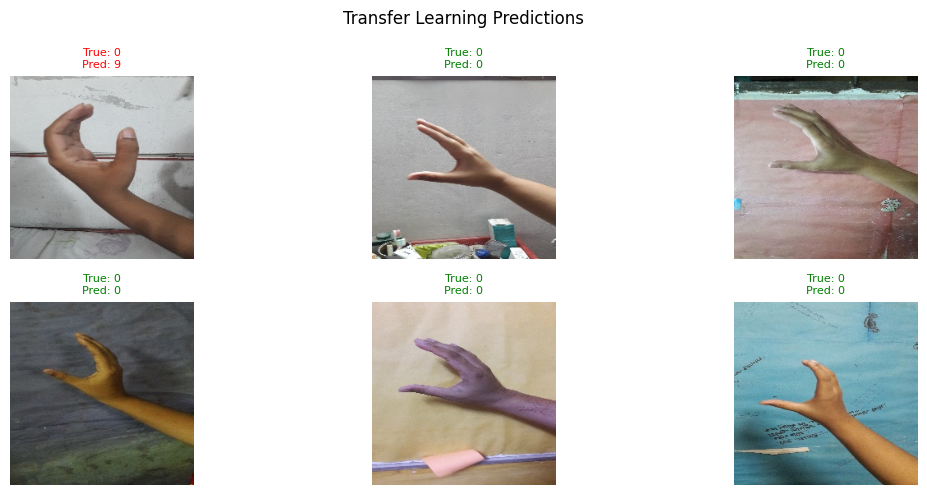

In [50]:

show_predictions(transfer_model, val_data_tl, "Transfer Learning Predictions")

Save best model

In [51]:
transfer_model.save("best_sign_language_model.keras")

Final Model Comparison Summary

In [52]:
baseline_acc = max(history_baseline.history['val_accuracy'])
deep_acc     = max(history_deep.history['val_accuracy'])
sgd_acc      = max(history_sgd.history['val_accuracy'])
tl_acc       = max(history_ft.history['val_accuracy'])

results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "Transfer Learning (MobileNetV2)"
    ],
    "Best Validation Accuracy": [
        baseline_acc,
        deep_acc,
        sgd_acc,
        tl_acc
    ],
    "Training Time (Seconds)": [
        baseline_train_time,
        deep_train_time,
        sgd_train_time,
        feature_extraction_time + fine_tuning_time
    ]
})

print(results.to_string(index=False))

                          Model  Best Validation Accuracy  Training Time (Seconds)
                   Baseline CNN                  0.786847              2253.865324
                Deep CNN (Adam)                  0.835821              2221.076089
                 Deep CNN (SGD)                  0.819496              2458.453957
Transfer Learning (MobileNetV2)                  0.853545              5741.397938


Final comparison plot

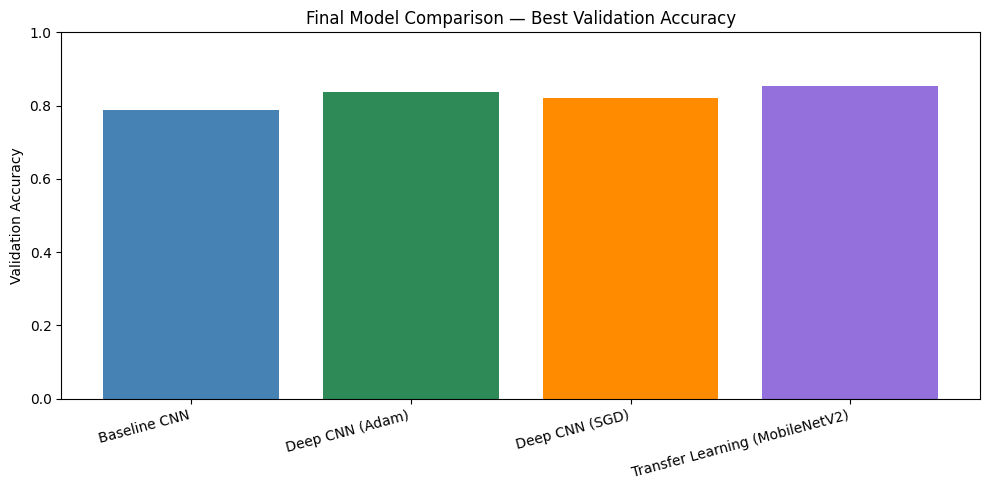

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["Best Validation Accuracy"], color=['steelblue', 'seagreen', 'darkorange', 'mediumpurple'])
plt.title("Final Model Comparison — Best Validation Accuracy")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()